In [474]:
import numpy as np
import matplotlib.pyplot as plt
x, w = np.polynomial.laguerre.laggauss(50)
xj, wj = np.polynomial.legendre.leggauss(50)
import ODESolve_slow as ODE


In [476]:
dm=1.293
gA=1.27
GF=1.66e-11
me=0.511


In [478]:
#antineutrino
def fanti(E,Tcm):
    fanti=(np.exp(E/Tcm)+1)**(-1)
    return fanti

In [480]:
#electron
def fe(E,T):
    fe=(np.exp(E/T)+1)**(-1)
    return fe

In [482]:
#integrand
def g(x,T,Tcm):
    delta=dm/Tcm
    u=me/Tcm
    g=(x**2)*(delta-x)*np.sqrt((delta-x)**2-u**2)*(1-fanti(x*Tcm,Tcm))*(1-fe((delta-x)*Tcm,T))
    return g

In [522]:
#Neutron Decay Rate


def N(T,a):
    Tcm=1/a
    delta=dm/Tcm
    u=me/Tcm
    integrand=np.zeros(50)
    A=delta-u
  
    for j in range(len(integrand)):
        E=(A/2)*(xj[j]+1)
        integrand[j] = g(E,T,Tcm)
    return ((GF**2)/(2*np.pi**3))*(1+(3*(gA**2)))*(Tcm**5)*(A/2)*np.sum(wj*integrand)  


In [524]:
#solve ODE
a0=0.1    
y0=np.array([10,0])
dx0=0.001
p=None

N_step = 1000
dN = 2
x_final = 100
a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

True


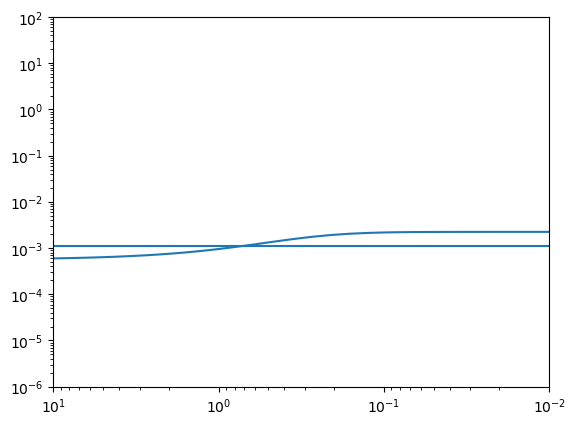

In [525]:
plt.figure()
T = y[:,0]
z = np.zeros(len(T))
for i in range(len(T)):
    z[i] = N(T[i],a[i])/(6.58e-22)
plt.loglog(1/a,z)
plt.xlim(1e1,1e-2)
plt.ylim(1e-6,1e2)
plt.axhline(1/903)


